In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# downgrading numpy, do this once, restart session, then don't run it again
# ! pip uninstall numpy && pip install "numpy<2.0"

In [ ]:
! pip install anndata --quiet
! pip install scanpy --quiet
! pip install python-igraph --quiet
! pip install leidenalg --quiet
! pip install imagecodecs --quiet
! pip install bin2cell --quiet
! pip install bin2cell[stardist] --quiet

In [ ]:
import scanpy as sc
import leidenalg
import bin2cell as b2c
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import os
import warnings
import imagecodecs
warnings.filterwarnings('ignore')

## bin2cell

In [97]:
# configs
# input paths
BASE_PATH = '/content/drive/MyDrive/mansfield-lab/visium/cell_segmentation/AB01_bin2cell/'
BIN_PATH = BASE_PATH + 'square_002um/'
SOURCE_IMAGE_PATH = BASE_PATH + 'AB01.tiff'
SPACERANGER_IMAGE_PATH = BASE_PATH + 'square_002um/spatial/'

# output paths
STARDIST_DIR = BASE_PATH + 'new/'
os.makedirs(STARDIST_DIR, exist_ok=True)

# parameters
MPP = 0.5028992777554675      # microns per pixel for image rescaling
PROB_THRESH_HE = 0.0003      # probability threshold for H&E segmentation (highest tried: 0.01)
PROB_THRESH_GEX = 0.05      # probability threshold for GEX segmentation (default: 0.05)
NMS_THRESH_HE = 0.3         # non-maximum suppression for H&E
NMS_THRESH_GEX = 0.5        # non-maximum suppression for GEX (default: 0.5)
MAX_BIN_DISTANCE = 2        # distance for label expansion
SIGMA = 5                   # gaussian smoothing for GEX image

In [51]:
# load data
print("=" * 80)
print("step 1: load visium data")
print("=" * 80)

adata = b2c.read_visium(
    BIN_PATH,
    source_image_path=SOURCE_IMAGE_PATH,
    spaceranger_image_path=SPACERANGER_IMAGE_PATH
)
adata.var_names_make_unique()

print(f"loaded data: {adata.n_obs} bins x {adata.n_vars} genes")
print(adata)

step 1: load visium data
loaded data: 4981472 bins x 19071 genes
AnnData object with n_obs × n_vars = 4981472 × 19071
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [52]:
adata.X.max()

109.0

In [53]:
print("\n" + "=" * 80)
print('step 2: data cleaning')
print("=" * 80)

# filter genes expressed in at least 3 spots
sc.pp.filter_genes(adata, min_cells=3)

# filter spots with <1 count
sc.pp.filter_cells(adata, min_counts=1)

print(f"after filtering: {adata.n_obs} bins x {adata.n_vars} genes")


step 2: data cleaning
after filtering: 2525920 bins x 19033 genes


In [54]:
print("\n" + "=" * 80)
print("step 3: preparing H&E image for nuclei segmentation")
print("=" * 80)

# create scaled H&E image for StarDist
b2c.scaled_he_image(
    adata,
    mpp=MPP,
    save_path=STARDIST_DIR + "he_scaled.tiff"
)

print(f"Scaled H&E image created at {MPP} mpp")
print(f"New spatial key: spatial_cropped_150_buffer")
print(f"New image key: {MPP}_mpp_150_buffer")


step 3: preparing H&E image for nuclei segmentation
Cropped spatial coordinates key: spatial_cropped_150_buffer
Image key: 0.5028992777554675_mpp_150_buffer
Scaled H&E image created at 0.5028992777554675 mpp
New spatial key: spatial_cropped_150_buffer
New image key: 0.5028992777554675_mpp_150_buffer


Visium HD suffers from variable bin sizing. When printing the chips, the 2um bins have some variability in their width/height. Inspecting the total counts per spot reveals a characteristic striped appearance, with some rows/columns capturing visibly fewer transcripts than others.

To overcome this, `b2c.destripe()` identifies a user-specified quantile (by default 0.99) of total counts for each row, then divides the counts of the spots in that row by that value. This procedure is then repeated for the columns. `.obs[adjusted_counts_key]` (by default `n_counts_adjusted`) is obtained by multiplying the resulting per-spot factor by the global quantile of count totals, and the count matrix is by default rescaled to match it.

In [55]:
# save raw counts before destriping modifies it in place
adata.layers['raw_counts'] = adata.X.copy()
adata

AnnData object with n_obs × n_vars = 2525920 × 19033
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

In [56]:
# # skip for now
# print("\n" + "=" * 80)
# print("step 4: correcting for striped pattern in H&E image")
# print("=" * 80)

# # correct for row/column variability in 2um bins
# b2c.destripe(adata)

# print("Destriping complete. Adjusted counts stored in 'n_counts_adjusted'")

In [57]:
# adata.layers['destriped_counts'] = adata.X.copy()
# adata

In [58]:
# # inspect stripe pattern
# # define a mask of ROI - this is BAT right side on E13.5

# # imagej coords
# imagej_xmin = 4900
# imagej_ymin = 2500
# imagej_xmax = 6528
# imagej_ymax = 4000

# # spatial_cropped_150_buffer coords
# spatial_cropped = adata.obsm['spatial_cropped_150_buffer']

# mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
#         (spatial_cropped[:, 0] <= imagej_xmax) &
#         (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
#         (spatial_cropped[:, 1] <= imagej_ymax))


# bdata = adata[mask]
# sc.pl.spatial(bdata, color=[None, 'n_counts', 'n_counts_adjusted'], color_map='OrRd', img_key=f'{MPP}_mpp_150_buffer', basis='spatial_cropped_150_buffer')

In [59]:
# nuclei segmentation
print("\n" + "=" * 80)
print('step 5: nuclei segmentation with stardist (H&E)')
print("=" * 80)

# run StarDist on H&E image
b2c.stardist(
    image_path=STARDIST_DIR + "he_scaled.tiff",
    labels_npz_path=STARDIST_DIR + "he.npz",
    stardist_model="2D_versatile_he",
    prob_thresh=PROB_THRESH_HE,
    nms_thresh=NMS_THRESH_HE
)

print("H&E-based nuclei segmentation complete")

# load nuclei labels into adata
b2c.insert_labels(
    adata,
    labels_npz_path=STARDIST_DIR + "he.npz",
    basis="spatial",
    spatial_key="spatial_cropped_150_buffer",
    mpp=MPP,
    labels_key="labels_he"
)

n_nuclei = (adata.obs['labels_he'] > 0).sum()
print(f"Detected {n_nuclei:,} nuclei")


step 5: nuclei segmentation with stardist (H&E)
Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
Overriding with prob_thresh=0.0003
Overriding with nms_thresh=0.3
effective: block_size=(4096, 4096, 3), min_overlap=(128, 128, 0), context=(128, 128, 0)


100%|██████████| 16/16 [03:22<00:00, 12.66s/it]


Found 111592 objects
H&E-based nuclei segmentation complete
Detected 1,040,976 nuclei


In [62]:
adata

AnnData object with n_obs × n_vars = 2525920 × 19033
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'labels_he'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial', 'bin2cell'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

In [63]:
# define a mask of ROI - this is BAT right side on E13.5

# imagej coords
imagej_xmin = 4900
imagej_ymin = 2500
imagej_xmax = 6528
imagej_ymax = 4000

# spatial_cropped_150_buffer coords
spatial_cropped = adata.obsm['spatial_cropped_150_buffer']

mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
        (spatial_cropped[:, 0] <= imagej_xmax) &
        (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
        (spatial_cropped[:, 1] <= imagej_ymax))


bdata = adata[mask]

In [64]:
bdata

View of AnnData object with n_obs × n_vars = 134931 × 19033
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'labels_he'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial', 'bin2cell'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

In [65]:
# visualize the expanded labels
# the labels obs are integers, 0 means unassigned
# ensure 'labels_he' is a numerical type for comparison before filtering
bdata.obs['labels_he'] = bdata.obs['labels_he'].astype(int)
bdata = bdata[bdata.obs['labels_he'] > 0]
# after filtering, convert to string for plotting if desired
bdata.obs['labels_he'] = bdata.obs['labels_he'].astype(str)

sc.set_figure_params(dpi=200)
sc.pl.spatial(bdata, color=[None, 'labels_he'], img_key=f'{MPP}_mpp_150_buffer', basis='spatial_cropped_150_buffer', legend_loc=None)

Output hidden; open in https://colab.research.google.com to view.

In [66]:
# visualize segmentation
# the label viewer wants a crop of the processed image
# get the corresponding coordinates spanning the subset object
crop = b2c.get_crop(bdata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)

rendered = b2c.view_labels(image_path=STARDIST_DIR+"he_scaled.tiff",
                           labels_npz_path=STARDIST_DIR+"he.npz",
                           crop=crop)
plt.imshow(rendered)

Output hidden; open in https://colab.research.google.com to view.

StarDist’s H&E segmentation merely identifies nuclei, while there’s more to a cell than just the nucleus. `b2c.expand_labels()` finds bins up to `max_bin_distance` (by default 2) bins away from a labelled nucleus, and joins them into the corresponding cell. Alternately, passing `algorithm="volume_ratio"` has each label get a custom expansion distance derived from its bin count, based on the linear relationship between cell and nuclear volume, controlled by volume_ratio with a default of 4. In the event of a bin being equidistant from multiple nuclei, it’s assigned to one based on the similarity of their gene expression profiles, as represented in PCA space.

In [ ]:
# print("\n" + "=" * 80)
# print("step 6: expanding nuclei to cell boundaries")
# print("=" * 80)

# # expand nuclei labels to approximate cell boundaries (using max_bin_distance=2 - default)
# b2c.expand_labels(
#     adata,
#     labels_key='labels_he',
#     expanded_labels_key='labels_he_expanded',
#     max_bin_distance=MAX_BIN_DISTANCE
# )

# n_expanded = (adata.obs['labels_he_expanded'] > 0).sum()
# print(f"Expanded to {n_expanded:,} bins")

In [ ]:
# visualize expanded label with max_bin_distance=2
# the labels obs are integers, 0 means unassigned
# bdata.obs['labels_he_expanded'] = bdata.obs['labels_he_expanded'].astype(int)
# bdata = bdata[bdata.obs['labels_he_expanded']>0]
# bdata.obs['labels_he_expanded'] = bdata.obs['labels_he_expanded'].astype(str)

# sc.set_figure_params(dpi=200)
# sc.pl.spatial(bdata, color=[None, 'labels_he_expanded'], img_key=f'{MPP}_mpp_150_buffer', basis='spatial_cropped_150_buffer', legend_loc=None)

In [67]:
print("\n" + "=" * 80)
print("step 6: expanding nuclei to cell boundaries")
print("=" * 80)

# expand nuclei labels to approximate cell boundaries (using volume_ratio=4 - default)
b2c.expand_labels(
    adata,
    labels_key='labels_he',
    expanded_labels_key='labels_he_expanded',
    algorithm="volume_ratio",
    volume_ratio=4
    )

n_expanded = (adata.obs['labels_he_expanded'] > 0).sum()
print(f"Expanded to {n_expanded:,} bins")


step 6: expanding nuclei to cell boundaries
Expanded to 1,501,826 bins


In [70]:
adata

AnnData object with n_obs × n_vars = 2525920 × 19033
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'labels_he', 'labels_he_expanded'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial', 'bin2cell'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

`volume_ratio` represents the ratio of cell volume to nuclear volume.

In [71]:
# visualize expanded label with volume_ratio=4
# the labels obs are integers, 0 means unassigned
bdata.obs['labels_he_expanded'] = adata.obs['labels_he_expanded'].astype(int)
bdata = bdata[bdata.obs['labels_he_expanded']>0]
bdata.obs['labels_he_expanded'] = bdata.obs['labels_he_expanded'].astype(str)

sc.set_figure_params(dpi=200)
sc.pl.spatial(bdata, color=[None, 'labels_he_expanded'], img_key=f'{MPP}_mpp_150_buffer', basis='spatial_cropped_150_buffer', legend_loc=None)

Output hidden; open in https://colab.research.google.com to view.

The above method performs best for sparse tissue, so a secondary method (GEX-based) is used for denser regions. The input image here is going to be a representation of the total counts per bin, with a Gaussian filter with a sigma of 5 (measured in pixels) applied for a little smoothing, basically creating a pseudo-fluorescense image from total counts. This one uses StarDist's fluorescence model, which detects cells instead of nuclei, so subsequent labels expansion is not necessary.

In [72]:
print("\n" + "=" * 80)
print("step 7: GEX-based cell segmentation (secondary)")
print("=" * 80)

# create pseudo-fluorescence image from total counts
b2c.grid_image(
    adata,
    "n_counts",
    mpp=MPP,
    sigma=5,
    save_path=STARDIST_DIR + "gex.tiff"
)

print("Generated GEX pseudo-fluorescence image")

# run StarDist on GEX image
b2c.stardist(
    image_path=STARDIST_DIR + "gex.tiff",
    labels_npz_path=STARDIST_DIR + "gex.npz",
    stardist_model="2D_versatile_fluo",
    prob_thresh=PROB_THRESH_GEX,
    nms_thresh=NMS_THRESH_GEX
)

print("GEX-based cell segmentation complete")

# load GEX labels
b2c.insert_labels(
    adata,
    labels_npz_path=STARDIST_DIR + "gex.npz",
    basis="array",
    mpp=MPP,
    labels_key="labels_gex"
)

n_gex_cells = (adata.obs['labels_gex'] > 0).sum()
print(f"Detected {n_gex_cells:,} GEX-based cells")


step 7: GEX-based cell segmentation (secondary)
Generated GEX pseudo-fluorescence image
Found model '2D_versatile_fluo' for 'StarDist2D'.
5320433/5320433 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Overriding with prob_thresh=0.05
Overriding with nms_thresh=0.5
effective: block_size=(4096, 4096), min_overlap=(128, 128), context=(128, 128)


100%|██████████| 16/16 [01:18<00:00,  4.92s/it]


Found 14079 objects
GEX-based cell segmentation complete
Detected 526,161 GEX-based cells


In [73]:
# visualize cells identified by GEX
bdata = adata[mask]

# the labels obs are integers, 0 means unassigned
bdata.obs['labels_gex'] = bdata.obs['labels_gex'].astype(int)
bdata = bdata[bdata.obs['labels_gex']>0]
bdata.obs['labels_gex'] = bdata.obs['labels_gex'].astype(str)

sc.set_figure_params(dpi=200)
sc.pl.spatial(bdata, color=[None, "labels_gex"], img_key=f"{MPP}_mpp_150_buffer", basis="spatial_cropped_150_buffer", legend_loc=None)

Output hidden; open in https://colab.research.google.com to view.

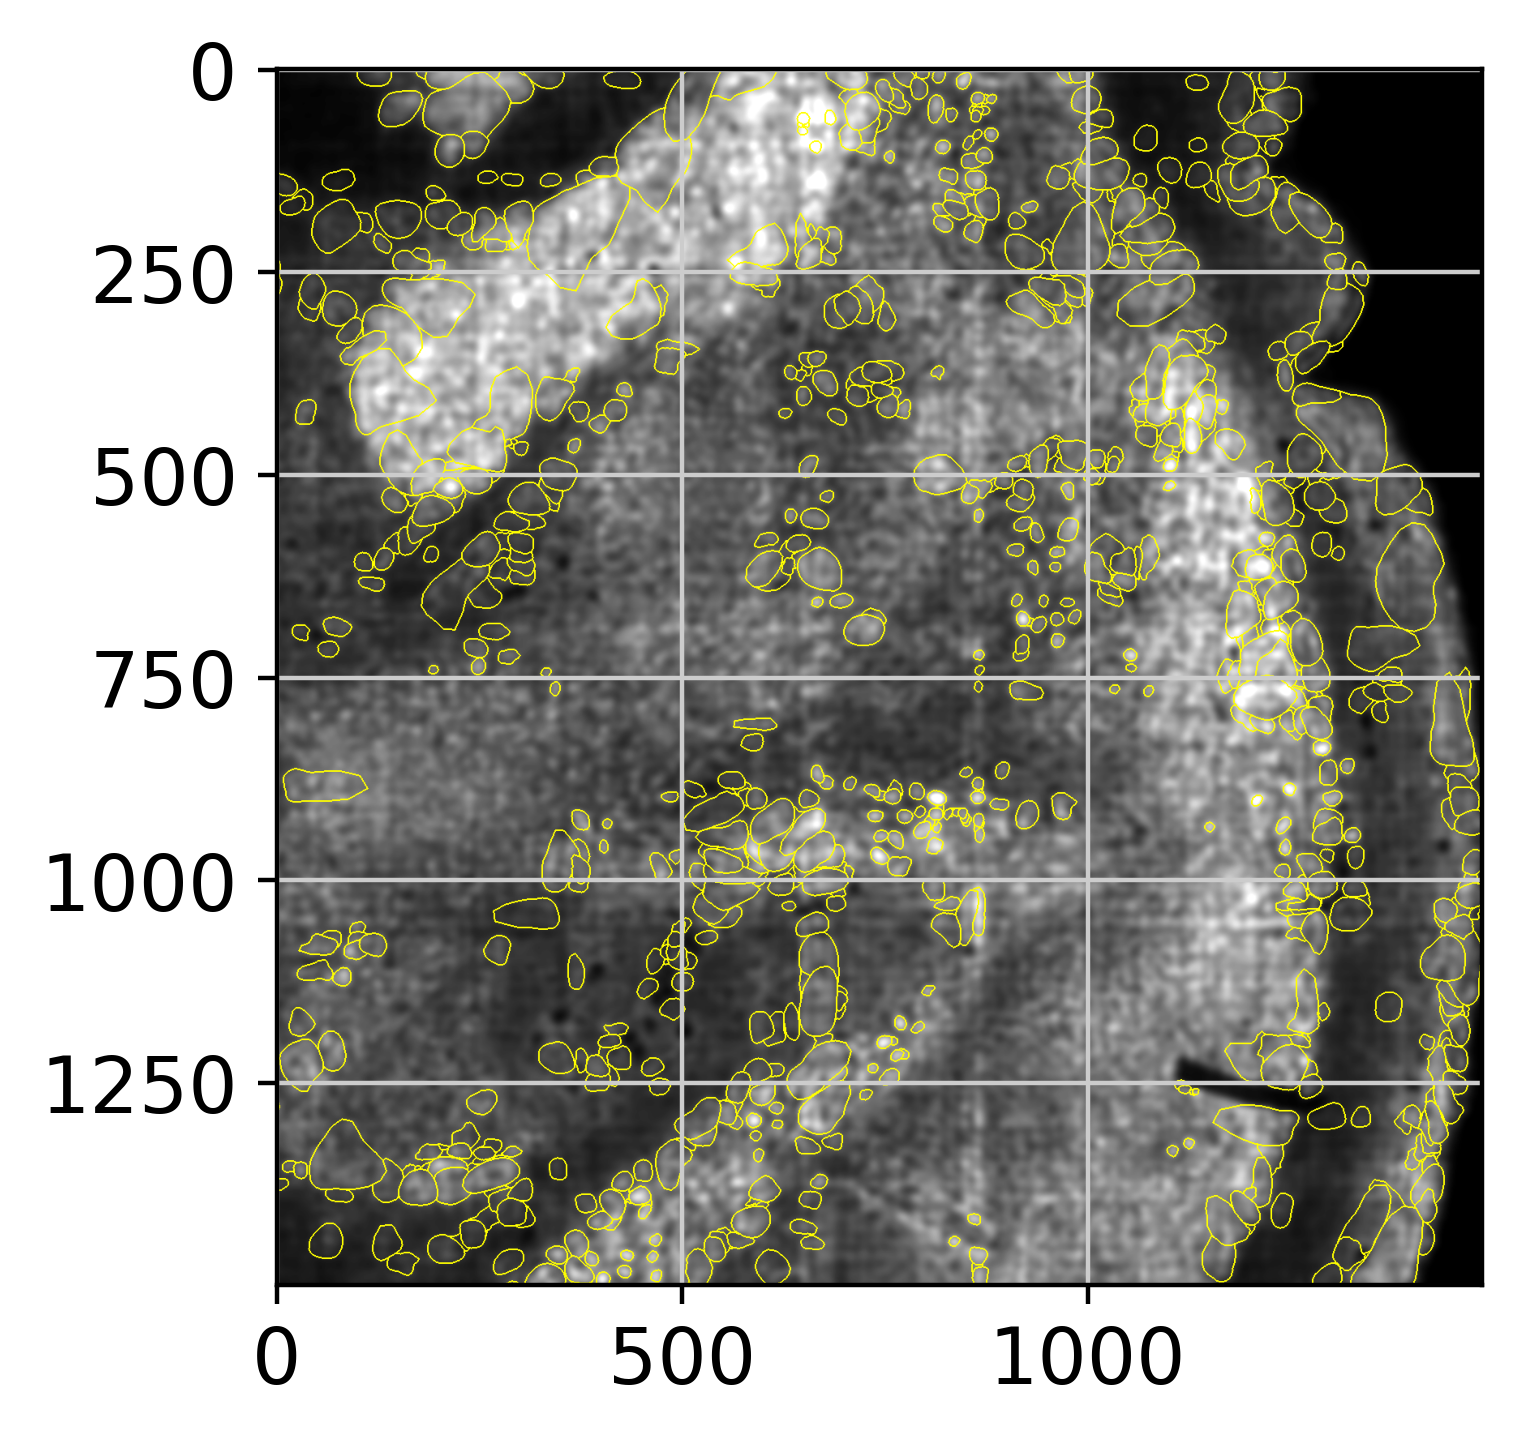

In [74]:
# visualize segmentation by GEX
# the label viewer wants a crop of the processed image
# get the corresponding coordinates spanning the subset object
crop = b2c.get_crop(bdata, basis="array", mpp=MPP)

# GEX pops better with percentile normalization performed
rendered = b2c.view_labels(image_path=STARDIST_DIR+"gex.tiff",
                           labels_npz_path=STARDIST_DIR+"gex.npz",
                           crop=crop,
                           stardist_normalize=True
                          )
plt.imshow(rendered)

In [75]:
print("\n" + "=" * 80)
print("step 8: combining H&E and GEX Labels")
print("=" * 80)

# add GEX cells that do not overlap with H&E labels
b2c.salvage_secondary_labels(
    adata,
    primary_label="labels_he_expanded",
    secondary_label="labels_gex",
    labels_key="labels_joint"
)

n_final_bins = (adata.obs['labels_joint'] > 0).sum()
print(f"Final segmented bins: {n_final_bins:,}")


step 8: combining H&E and GEX Labels
Salvaged 243 secondary labels
Final segmented bins: 1,507,068


In [76]:
# visualize where the labels come from (primary or secondary)
bdata = adata[mask]

# the labels obs are integers, 0 means unassigned
bdata.obs['labels_joint'] = bdata.obs['labels_joint'].astype(int)
bdata = bdata[bdata.obs['labels_joint']>0]
bdata.obs['labels_joint'] = bdata.obs['labels_joint'].astype(str)

sc.pl.spatial(bdata, color=[None, "labels_joint_source", "labels_joint"], img_key=f"{MPP}_mpp_150_buffer", basis="spatial_cropped_150_buffer", legend_loc=None)

Output hidden; open in https://colab.research.google.com to view.

In [77]:
print("\n" + "=" * 80)
print("step 9: grouping bins into cells")
print("=" * 80)

# group bins belonging to same cell
cdata = b2c.bin_to_cell(
    adata,
    labels_key="labels_joint",
    spatial_keys=["spatial", "spatial_cropped_150_buffer"]
)

print(f"Created cell-level data: {cdata.n_obs:,} cells x {cdata.n_vars} genes")
print(cdata)

# check source of labels
source_counts = cdata.obs['labels_joint_source'].value_counts()
print(f"\nLabel sources:")
for source, count in source_counts.items():
    print(f"  {source}: {count:,} cells ({count/cdata.n_obs*100:.1f}%)")


step 9: grouping bins into cells
Created cell-level data: 111,577 cells x 19033 genes
AnnData object with n_obs × n_vars = 111577 × 19033
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

Label sources:
  primary: 111,334 cells (99.8%)
  secondary: 243 cells (0.2%)


In [78]:
# imagej coords
imagej_xmin = 4900
imagej_ymin = 2500
imagej_xmax = 6528
imagej_ymax = 4000

# spatial_cropped_150_buffer coords
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

cell_mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
              (spatial_cropped[:, 0] <= imagej_xmax) &
              (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
              (spatial_cropped[:, 1] <= imagej_ymax))

ddata = cdata[cell_mask]
sc.pl.spatial(ddata, color=["bin_count", "labels_joint_source"], img_key=f"{MPP}_mpp_150_buffer", basis="spatial_cropped_150_buffer", legend_loc=None)

Output hidden; open in https://colab.research.google.com to view.

In [89]:
crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
# this is a string at this time
cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"he_scaled.tiff",
                                    labels_npz_path=STARDIST_DIR+"he.npz",
                                    cdata=cdata,
                                    crop=crop,
                                    fill_key="Sox9",
                                    border_key="labels_joint_source",
                                    cont_cmap='gnuplot'
                                   )
plt.imshow(img)

Output hidden; open in https://colab.research.google.com to view.

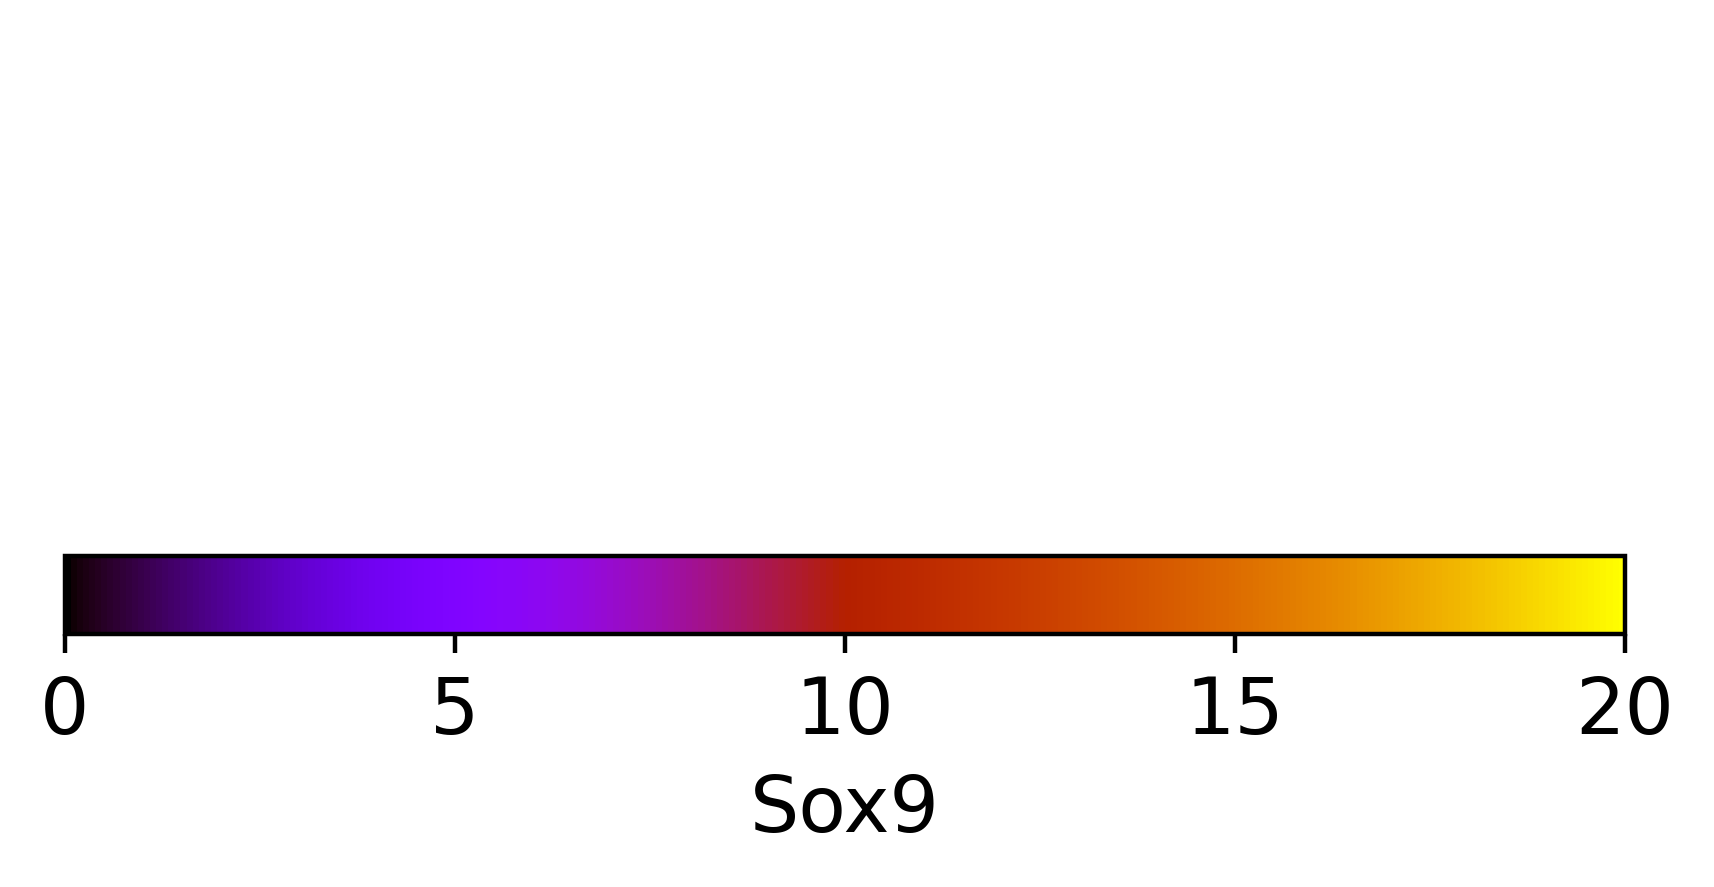

In [90]:
legends["Sox9"]

In [95]:
cdata.layers['raw_counts'] = cdata.X.copy()
cdata

AnnData object with n_obs × n_vars = 111577 × 19033
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    layers: 'raw_counts'

In [ ]:
# imagej coords
imagej_xmin = 2752
imagej_ymin = 1184
imagej_xmax = 3920
imagej_ymax = 2272

# spatial_cropped_150_buffer coords
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

cell_mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
              (spatial_cropped[:, 0] <= imagej_xmax) &
              (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
              (spatial_cropped[:, 1] <= imagej_ymax))

ddata = cdata[cell_mask]

crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"he_scaled. tiff",
                                    labels_npz_path=STARDIST_DIR+"he.npz",
                                    cdata=cdata,
                                    crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)

In [ ]:
# imagej coords
imagej_xmin = 1280
imagej_ymin = 2400
imagej_xmax = 2320
imagej_ymax = 3504

# spatial_cropped_150_buffer coords
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

cell_mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
              (spatial_cropped[:, 0] <= imagej_xmax) &
              (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
              (spatial_cropped[:, 1] <= imagej_ymax))

ddata = cdata[cell_mask]

crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"he_scaled.tiff",
                                    labels_npz_path=STARDIST_DIR+"he.npz",
                                    cdata=cdata,
                                    crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)

In [ ]:
ROI = [
    [2816, 959, 3952, 2159],
    [5984, 960, 5040, 2144],
    [5040, 960, 5936, 2144],
    [1536, 960, 2816, 2144],
    [1151, 2175, 2192, 3343],
    [2176, 2160, 3264, 3328],
    [2295, 2175, 4255, 3359],
    [4256, 2144, 5232, 3344],
    [5232, 2144, 6320, 3344],
    [880, 3344, 1936, 4336],
    [1936, 3359, 3008, 4383],
    [3024, 3344, 4128, 4368],
    [4128, 3360, 5104, 4368],
    [5104, 3375, 6384, 4399],
    [880, 4336, 1936, 5200],
    [1936, 4384, 3008, 5200],
    [3024, 4384, 4128, 5184],
    [4144, 4384, 5120, 5200],
    [5120, 4400, 6144, 5200],
    [864, 5231, 1936, 5903],
    [1936, 5216, 2992, 5872],
    [3008, 5216, 4144, 5904],
    [4144, 5216, 5152, 5664],
    [6640, 5712, 7680, 6592],
    [7680, 5728, 8608, 6592],
    [8315, 6608, 7147, 7456],
    [7136, 6623, 8016, 7471],
    [8016, 6623, 8880, 7503],
    [6288, 7472, 7152, 8320],
    [7152, 7487, 8016, 8351],
    [8016, 7472, 8912, 8336],
    [6900, 7008, 9700, 7888],
    [6896, 7024, 10416, 7888],
    [10035, 6208, 10931, 7024],
    [10432, 7024, 10960, 7680],
    [6288, 8320, 7152, 9008],
    [7152, 8367, 8032, 9119],
    [8032, 8352, 8912, 9104],
    [8912, 7904, 9504, 8816],
    [8504, 7904, 10128, 8496]
]

In [ ]:
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

for idx, i in enumerate(ROI, start=1):
  # corrected cell_mask creation: i is [xmin, ymin, xmax, ymax]
  cell_mask = ((spatial_cropped[:, 0] >= i[0]) &
                (spatial_cropped[:, 0] <= i[2]) &
                (spatial_cropped[:, 1] >= i[1]) &
                (spatial_cropped[:, 1] <= i[3]))
  ddata = cdata[cell_mask]

  # check if ddata is empty before proceeding
  if ddata.n_obs == 0:
      print(f"Warning: ROI {idx} resulted in an empty dataset. Skipping visualization.")
      continue

  crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
  cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

  img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"he_scaled.tiff",
                                      labels_npz_path=STARDIST_DIR+"he.npz",
                                      cdata=cdata,
                                      crop=crop,
                                      fill_key="bin_count",
                                      border_key="labels_joint_source")
  plt.imshow(img)
  plt.savefig(STARDIST_DIR+f'crop_{idx:02d}.png', bbox_inches='tight', dpi=200)
  plt.close()

In [ ]:
# ROI 2
# imagej coords
imagej_xmin = 3984
imagej_ymin = 960
imagej_xmax = 5040
imagej_ymax = 2144

# spatial_cropped_150_buffer coords
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

cell_mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
              (spatial_cropped[:, 0] <= imagej_xmax) &
              (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
              (spatial_cropped[:, 1] <= imagej_ymax))

ddata = cdata[cell_mask]

crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"he_scaled.tiff",
                                    labels_npz_path=STARDIST_DIR+"he.npz",
                                    cdata=cdata,
                                    crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)
plt.savefig(STARDIST_DIR+f'crop_02.png', bbox_inches='tight', dpi=200)
plt.close()

In [ ]:
# ROI 26
# imagej coords
imagej_xmin = 6315
imagej_ymin = 6608
imagej_xmax = 7147
imagej_ymax = 7456

# spatial_cropped_150_buffer coords
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

cell_mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
              (spatial_cropped[:, 0] <= imagej_xmax) &
              (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
              (spatial_cropped[:, 1] <= imagej_ymax))

ddata = cdata[cell_mask]

crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"he_scaled.tiff",
                                    labels_npz_path=STARDIST_DIR+"he.npz",
                                    cdata=cdata,
                                    crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)
plt.savefig(STARDIST_DIR+f'crop_26.png', bbox_inches='tight', dpi=200)
plt.close()

In [ ]:
# ROI 7
# imagej coords
imagej_xmin = 2176
imagej_ymin = 2160
imagej_xmax = 3264
imagej_ymax = 3328

# spatial_cropped_150_buffer coords
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

cell_mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
              (spatial_cropped[:, 0] <= imagej_xmax) &
              (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
              (spatial_cropped[:, 1] <= imagej_ymax))

ddata = cdata[cell_mask]

crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"results_1115/files/he_scaled.tiff",
                                    labels_npz_path=STARDIST_DIR+"results_1115/files/he.npz",
                                    cdata=cdata,
                                    crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)
# plt.savefig(STARDIST_DIR+'crop_7.png', bbox_inches='tight', dpi=200)
# plt.close()

In [ ]:
# ROI 32
# imagej coords
imagej_xmin = 8900
imagej_ymin = 7008
imagej_xmax = 9700
imagej_ymax = 7888

# spatial_cropped_150_buffer coords
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

cell_mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
              (spatial_cropped[:, 0] <= imagej_xmax) &
              (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
              (spatial_cropped[:, 1] <= imagej_ymax))

ddata = cdata[cell_mask]

crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"results_1115/files/he_scaled.tiff",
                                    labels_npz_path=STARDIST_DIR+"results_1115/files/he.npz",
                                    cdata=cdata,
                                    crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)
# plt.savefig(STARDIST_DIR+'crop_7.png', bbox_inches='tight', dpi=200)
# plt.close()

In [ ]:
# ROI 33
# imagej coords
imagej_xmin = 9696
imagej_ymin = 7024
imagej_xmax = 10416
imagej_ymax = 7888

# spatial_cropped_150_buffer coords
spatial_cropped = cdata.obsm['spatial_cropped_150_buffer']

cell_mask = ((spatial_cropped[:, 0] >= imagej_xmin) &    # all rows, first column (x-coordinates)
              (spatial_cropped[:, 0] <= imagej_xmax) &
              (spatial_cropped[:, 1] >= imagej_ymin) &    # all rows, first column (y-coordinates)
              (spatial_cropped[:, 1] <= imagej_ymax))

ddata = cdata[cell_mask]

crop = b2c.get_crop(ddata, basis="spatial", spatial_key="spatial_cropped_150_buffer", mpp=MPP)
cdata.obs["labels_joint_source"] = cdata.obs["labels_joint_source"].astype("category")

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"results_1115/files/he_scaled.tiff",
                                    labels_npz_path=STARDIST_DIR+"results_1115/files/he.npz",
                                    cdata=cdata,
                                    crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)
# plt.savefig(STARDIST_DIR+'crop_7.png', bbox_inches='tight', dpi=200)
# plt.close()

In [ ]:
# THE WHOLE IMAGE

img, legends = b2c.view_cell_labels(image_path=STARDIST_DIR+"results_1115/files/he_scaled.tiff",
                                    labels_npz_path=STARDIST_DIR+"results_1115/files/he.npz",
                                    cdata=cdata,
                                    # crop=crop,
                                    fill_key="bin_count",
                                    border_key="labels_joint_source")
plt.imshow(img)
plt.savefig(STARDIST_DIR+'results_1115/whole_image.png', dpi=800)
plt.close()

In [98]:
# cdata is the final h5ad output
cdata.write_h5ad(STARDIST_DIR + "AB01_b2c.h5ad", compression='gzip')